Epoch 1/3 | Train Loss: 0.4727 | Val Dice: 0.0000
Epoch 2/3 | Train Loss: 0.2537 | Val Dice: 0.7475
Epoch 3/3 | Train Loss: 0.2149 | Val Dice: 0.7584


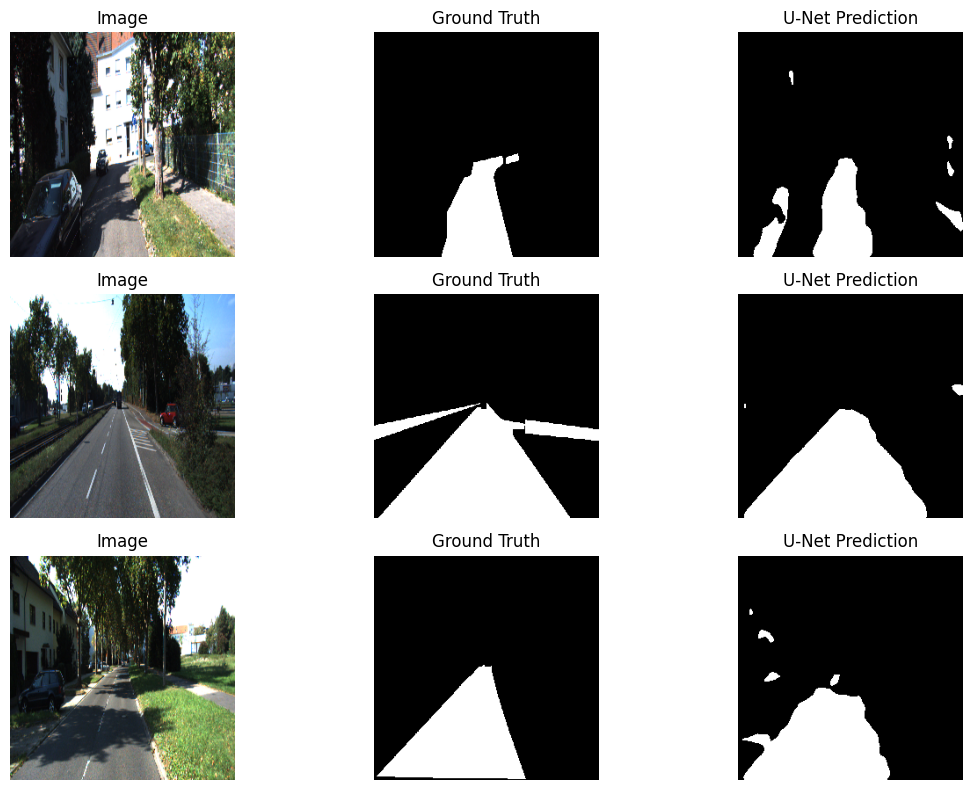

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_DIR = "../data/training/image_2"
MASK_DIR = "../data/training/gt_image_2"
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 3
LR = 1e-3


def get_mask_name(img_name):
    stem = img_name.replace(".png", "")
    prefix, idx = stem.split("_", 1)
    return f"{prefix}_road_{idx}.png"

all_images = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith(".png")])
random.shuffle(all_images)
split_idx = int(0.8 * len(all_images))
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]


class KITTIRoadDataset(Dataset):
    def __init__(self, image_names):
        self.image_names = image_names

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        mask_name = get_mask_name(img_name)

        img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0

        mask = cv2.imread(os.path.join(MASK_DIR, mask_name))
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        flat = mask.reshape(-1, 3)
        colors, counts = np.unique(flat, axis=0, return_counts=True)
        background_color = colors[np.argmax(counts)]
        gt = np.any(mask != background_color, axis=-1).astype(np.float32)

        img = np.transpose(img, (2, 0, 1))
        gt = np.expand_dims(gt, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(gt, dtype=torch.float32)

train_dataset = KITTIRoadDataset(train_images)
val_dataset = KITTIRoadDataset(val_images)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.out(u1)


def dice_score(pred, target, eps=1e-8):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

model = UNet().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_dices = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            val_dices.append(dice_score(preds, masks).item())

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Dice: {np.mean(val_dices):.4f}")


model.eval()
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float().cpu().numpy()

imgs = imgs.cpu().numpy()
masks = masks.cpu().numpy()

plt.figure(figsize=(12, 8))
for i in range(min(3, len(imgs))):
    img = np.transpose(imgs[i], (1, 2, 0))
    gt = masks[i, 0]
    pred = preds[i, 0]

    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(pred, cmap="gray")
    plt.title("U-Net Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()